In [1]:
import numpy as np
import numpy.linalg as mat, scipy.linalg as smat
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/dan/Documents/code');
from scvxplot import *
sys.path.remove('/Users/dan/Documents/code');

(CVXPY) Apr 29 08:45:08 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.7.2996). Expected < 9.5.0.Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 29 08:45:08 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.7.2996). Expected < 9.5.0.Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 29 08:45:08 PM: Encountered unexpected exception importing solver OSQP:
ImportError('dlopen(/Users/dan/miniconda3/lib/python3.11/site-packages/osqp/_osqp.cpython-311-darwin.so, 2): Symbol not found: _csc_matrix\n  Referenced from: /Users/dan/miniconda3/lib/python3.11/site-packages/osqp/_osqp.cpython-311-darwin.so\n  Expected in: flat namespace\n in /Users/dan/miniconda3/lib/python3.11/site-packages/osqp/_osqp.cpython-311-darwin.so')


## GENERATING TOY DATA

In [2]:
#### Constructing fake data
methodtags = ['nonlin1','nonlin2']
agenttags = ['agent'];
inittags = list(range(4));
sampletags = list(range(4));
epochtags = [0,1,2];
iterations = list(range(10));
waypttags = list(range(3));

####################################
nt = 100; nx = 4; nu = 2;
####################################
prob = 'prob1';
data = {};

data[prob] = {};
data[prob]['tag_types'] = ('method','agent','init','sample','epoch','itr','waypt');
data[prob]['state_types'] = {};
data[prob]['control_types'] = {};

data[prob]['states'] = {}
data[prob]['controls'] = {}

scl = 30; 
# for method in methodtags:
#     for agent in agenttags:
#         for init in inittags:
#             for sample in sampletags:
#                 for epoch in epochtags:
#                     for itr in iterations:
#                         for waypt in waypttags:
#                             tag = (method,init,sample,epoch,itr,waypt)

prods = itertools.product(methodtags,agenttags,inittags,sampletags,epochtags,iterations,waypttags)
for tag in prods:
    # tag = (method,init,sample,epoch,itr,waypt)
    states = np.outer(np.array(list(range(nt))),np.ones(nx));
    state_noise = scl*np.vstack([np.zeros(nt),np.random.rand(nt)-0.5,np.zeros([nx-2,nt])]).T
    ctrls = np.outer(np.array(list(range(nt))),np.ones(nu)); 
    ctrl_noise = scl*np.vstack([np.random.rand(nt)-0.5,np.zeros(nt),np.zeros([nu-2,nt])]).T
    
    data[prob]['states'][tag] = states + state_noise;
    data[prob]['controls'][tag] = ctrls + ctrl_noise; 
    data[prob]['state_types'][tag] = ('pos','pos','vel','vel');
    data[prob]['control_types'][tag] = ('force','force');

### load data from picklefile into probdata -- saved by optimization code (generated automatically)
### in a separate config file -- specify figdata (separate functions to create this)
figdata = {};
layerstyles = {};
layerstyles['states1'] = {'lw': 1,'lc': [0,0,1,0.3],'fc':[0,0,0,0.2],'mc': [0,0,0,1],'ms': 2,'msty': 'o'};
layerstyles['controls1'] = {'lw': 1,'lc': [1,0,0,0.3],'fc':[0,0,0,0.2],'mc': [0,0,0,1],'ms': 2,'msty': 'o'};

## CUSTOM PLOT TEMPLATE

In [3]:
def frame1example(ins):  ## HAVE A GOOD TEMPLATE
    ### use more exotic packages like pyvista, seaborn
    plotdata = ins['plotdata'];
    statedata = plotdata.data['prob1']['states'][(1,3,2,3,4,)];
    ls = plotdata.figs['prob1']['defaults']['ls']
    plt.plot(statedata[:,0],statedata[:,1],linestyle=ls) ### state trajectory

## MAIN FIGURE GENERATION

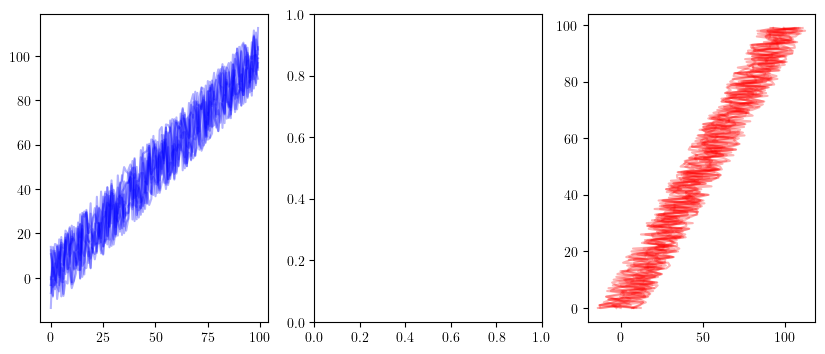

In [4]:
fig,axs = plt.subplots(1,3,figsize=(10,4))
ins = {};
ins['data'] = data; ins['figdata'] = figdata;
specific_instances = list(data[prob]['states'])[1:11];

PLOTS1 = SCVXPLOT(ins);
PLOTS1.addLayerStyles(layerstyles);
PLOTS1.plotStates(fig,axs[0],prob=prob,layer='states1',insts=specific_instances,args={'state_type':'pos'})
PLOTS1.plotControls(fig,axs[2],prob=prob,layer='controls1',insts=specific_instances,args={'control_type':'force'})


In [5]:
# print(specific_instances)